# 03 · Scaling with model size

Beyond data size, cost grows with model complexity: the number of mixture components K, the number of HMM states S (transition work is ~S²), the sequence length L, and the vocabulary V for categorical emissions. We hold N fixed and vary one axis at a time.


In [1]:

import time, io, numpy as np
import matplotlib.pyplot as plt
from mixle.stats import *
from mixle.inference.estimation import optimize
from mixle.stats.compute.sequence import seq_estimate

def bench(fn, repeat=3):
    """Best-of-`repeat` wall-clock seconds for calling fn()."""
    best = float('inf')
    for _ in range(repeat):
        t0 = time.perf_counter(); fn(); best = min(best, time.perf_counter() - t0)
    return best

def em_step_time(enc, est, model, iters=10):
    """Mean seconds per EM iteration (E+M step, excludes the convergence LL pass)."""
    from mixle.stats.compute.sequence import seq_estimate
    t0 = time.perf_counter()
    m = model
    for _ in range(iters):
        m = seq_estimate(enc, est, prev_estimate=m)
    return (time.perf_counter() - t0) / iters, m


## Mixture: cost vs number of components K


In [2]:
N = 50_000
rng = np.random.RandomState(0)
rows = []
for K in [2, 4, 8, 16, 32]:
    comps = [GaussianDistribution(float(i), 1.0) for i in range(K)]
    d = MixtureDistribution(comps, [1.0/K]*K); data = d.sampler(1).sample(N)
    est = MixtureEstimator([GaussianEstimator()]*K); enc = seq_encode(data, model=d)
    m = seq_estimate(enc, est, prev_estimate=d)
    per,_ = em_step_time(enc, est, m, iters=6)
    rows.append((K, per)); print('K=%2d   %.4f s/iter' % (K, per))
mix_K = np.array(rows, float)

K= 2   0.0091 s/iter
K= 4   0.0108 s/iter
K= 8   0.0149 s/iter


K=16   0.0272 s/iter


K=32   0.0586 s/iter


## HMM: cost vs number of states S (note the ~S² transition term)


In [3]:
rows = []
for S in [2, 4, 8, 16, 32]:
    topics = [GaussianDistribution(float(i), 1.0) for i in range(S)]
    d = HiddenMarkovModelDistribution(topics, [1.0/S]*S, np.full((S,S),1.0/S),
                                      len_dist=CategoricalDistribution({30:1.0}))
    data = d.sampler(1).sample(1000)
    est = HiddenMarkovEstimator([GaussianEstimator()]*S, use_numba=True)
    enc = seq_encode(data, model=d); m = seq_estimate(enc, est, prev_estimate=d)
    per,_ = em_step_time(enc, est, m, iters=6)
    rows.append((S, per)); print('S=%2d   %.4f s/iter' % (S, per))
hmm_S = np.array(rows, float)

S= 2   0.0134 s/iter


S= 4   0.0191 s/iter


S= 8   0.0298 s/iter


S=16   0.0623 s/iter


S=32   0.1932 s/iter


## HMM: cost vs sequence length L


In [4]:
rows = []
for L in [10, 20, 40, 80, 160]:
    topics = [GaussianDistribution(-2,1), GaussianDistribution(2,1)]
    d = HiddenMarkovModelDistribution(topics, [.5,.5], [[.8,.2],[.2,.8]],
                                      len_dist=CategoricalDistribution({L:1.0}))
    data = d.sampler(1).sample(1000)
    est = HiddenMarkovEstimator([GaussianEstimator()]*2, use_numba=True)
    enc = seq_encode(data, model=d); m = seq_estimate(enc, est, prev_estimate=d)
    per,_ = em_step_time(enc, est, m, iters=6)
    rows.append((L, per)); print('L=%3d   %.4f s/iter' % (L, per))
hmm_L = np.array(rows, float)

L= 10   0.0051 s/iter
L= 20   0.0091 s/iter


L= 40   0.0208 s/iter


L= 80   0.0379 s/iter


L=160   0.0684 s/iter


## Plots


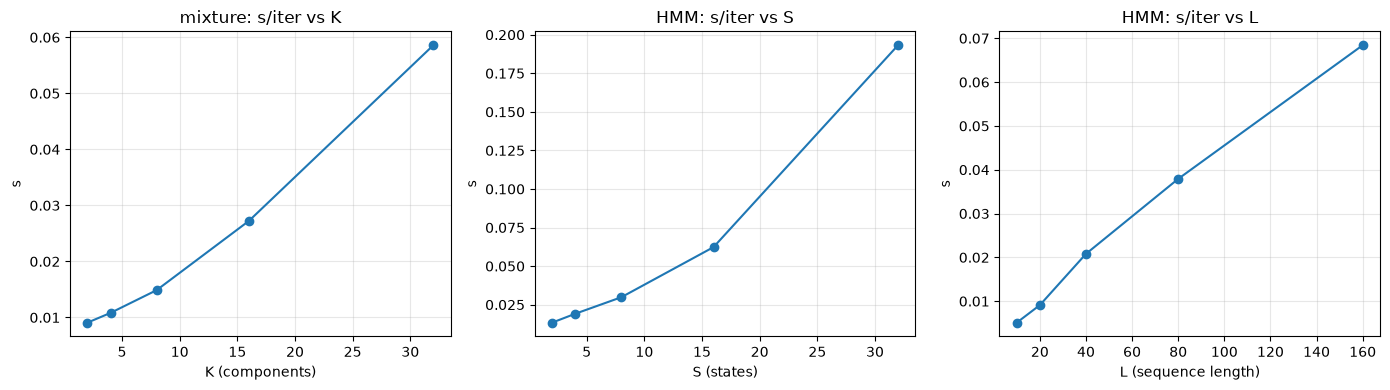

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(mix_K[:,0], mix_K[:,1], 'o-'); ax[0].set(title='mixture: s/iter vs K', xlabel='K (components)', ylabel='s')
ax[1].plot(hmm_S[:,0], hmm_S[:,1], 'o-'); ax[1].set(title='HMM: s/iter vs S', xlabel='S (states)', ylabel='s')
ax[2].plot(hmm_L[:,0], hmm_L[:,1], 'o-'); ax[2].set(title='HMM: s/iter vs L', xlabel='L (sequence length)', ylabel='s')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

### Takeaways
- Mixture cost grows ~linearly in K (each component scored over the batch).
- HMM cost grows faster than linear in S (the dense transition update is ~S²) and linearly in L.
- Pick the smallest adequate state space; for large S the numba HMM path (`use_numba=True`) and/or the torch engine (notebook 04) pay off.
